# KOL Backtest Explorer

Interactive analysis of `lumina_kol_monitor --backtest` JSONL output: outcomes, KOL buy notionals, dev sells, and how they relate.

**Configure** `JSONL_PATH` in the next cell to point at your file (e.g. `backtest_results/kol_backtest_60d.jsonl` or `kol_backtest_60d_kol2plus.jsonl`).

In [1]:
# Optional: install extras in this environment
# %pip install -q pandas numpy matplotlib seaborn plotly kaleido

In [2]:
from __future__ import annotations

import json
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import seaborn as sns
import plotly.express as px
import plotly.graph_objects as go
from plotly.subplots import make_subplots

# --- paths: repo root = parent of notebooks/
REPO = Path.cwd().resolve()
if REPO.name == "notebooks":
    REPO = REPO.parent

JSONL_PATH = REPO / "backtest_results" / "kol_backtest_60d_kol2plus.jsonl"
# JSONL_PATH = REPO / "backtest_results" / "kol_backtest_60d.jsonl"

assert JSONL_PATH.is_file(), f"Missing file: {JSONL_PATH}"

# Visual theme: high-contrast, non-generic
PALETTE = ["#0d9488", "#ea580c", "#7c3aed", "#dc2626", "#ca8a04", "#2563eb"]
BG = "#0f1419"
FG = "#e7e9ea"
MUTED = "#8b98a5"

plt.rcParams.update({
    "figure.facecolor": BG,
    "axes.facecolor": BG,
    "axes.edgecolor": MUTED,
    "axes.labelcolor": FG,
    "text.color": FG,
    "xtick.color": MUTED,
    "ytick.color": MUTED,
    "grid.color": "#2f3336",
    "grid.alpha": 0.6,
    "font.family": "DejaVu Sans",
    "figure.dpi": 120,
})
sns.set_theme(style="darkgrid", rc={"axes.facecolor": BG, "figure.facecolor": BG})

In [3]:
def load_kol_backtest_jsonl(path: Path) -> pd.DataFrame:
    rows = []
    with path.open() as f:
        for line in f:
            line = line.strip()
            if not line:
                continue
            r = json.loads(line)
            kbuys = r.get("kol_buys") or []
            notionals = [float(k.get("buy_notional_usd_approx") or 0) for k in kbuys]
            entry_mcaps_slot = [float(k.get("entry_mcap_usd") or 0) for k in kbuys]
            rows.append({
                "row": r.get("row"),
                "token": r.get("token"),
                "name": (r.get("name") or "")[:80],
                "kol_count": int(r.get("kol_count") or 0),
                "age_blocks": int(r.get("age_blocks") or 0),
                "create_block": int(r.get("create_block") or 0),
                "graduated": bool(r.get("graduated")),
                "entry_mcap_usd": float(r.get("entry_mcap_usd") or 0),
                "peak_mcap_usd": float(r.get("peak_mcap_usd") or 0),
                "low_mcap_usd": float(r.get("low_mcap_usd") or 0),
                "current_mcap_usd": float(r.get("current_mcap_usd") or 0),
                "peak_x": float(r.get("peak_x") or 0),
                "low_x": float(r.get("low_x") or 0),
                "dev_sell_tokens": float(r.get("dev_sell_tokens") or 0),
                "dev_sell_usd_approx": float(r.get("dev_sell_usd_approx") or 0),
                "n_kol_buys_logged": len(kbuys),
                "sum_kol_buy_usd": float(sum(notionals)),
                "max_kol_buy_usd": float(max(notionals)) if notionals else 0.0,
                "first_kol_buy_usd": float(notionals[0]) if notionals else 0.0,
                "second_kol_buy_usd": float(notionals[1]) if len(notionals) > 1 else 0.0,
                "third_kol_buy_usd": float(notionals[2]) if len(notionals) > 2 else 0.0,
            })
    df = pd.DataFrame(rows)
    df["log_entry_mcap"] = np.log1p(df["entry_mcap_usd"].clip(lower=0))
    df["log_dev_sell_usd"] = np.log1p(df["dev_sell_usd_approx"].clip(lower=0))
    df["peak_x_capped"] = df["peak_x"].clip(upper=50)
    return df


def kol_buys_long(df_raw_path: Path) -> pd.DataFrame:
    """One row per KOL buy event (for sequence / notional strips)."""
    out = []
    with df_raw_path.open() as f:
        for line in f:
            line = line.strip()
            if not line:
                continue
            r = json.loads(line)
            token = r.get("token")
            for i, k in enumerate(r.get("kol_buys") or []):
                out.append({
                    "token": token,
                    "kol_index": i + 1,
                    "kol": k.get("kol"),
                    "buy_notional_usd_approx": float(k.get("buy_notional_usd_approx") or 0),
                    "entry_mcap_usd_at_buy": float(k.get("entry_mcap_usd") or 0),
                    "buy_block": int(k.get("buy_block") or 0),
                })
    return pd.DataFrame(out)


df = load_kol_backtest_jsonl(JSONL_PATH)
df_long = kol_buys_long(JSONL_PATH)
print(f"Loaded {len(df):,} tokens from {JSONL_PATH.name}")
print(f"KOL buy events (long): {len(df_long):,}")
df.head(3)

Loaded 394 tokens from kol_backtest_60d_kol2plus.jsonl
KOL buy events (long): 1,108


,row,token,name,kol_count,age_blocks,create_block,graduated,entry_mcap_usd,peak_mcap_usd,low_mcap_usd,...,dev_sell_usd_approx,n_kol_buys_logged,sum_kol_buy_usd,max_kol_buy_usd,first_kol_buy_usd,second_kol_buy_usd,third_kol_buy_usd,log_entry_mcap,log_dev_sell_usd,peak_x_capped
0,2,0x0654a25e5fa6118068e58df07a738e4cdf5e4444,AgentPay SDK,2,46427,87553101,True,58800.0,58800.0,58800.0,...,291.0,2,470.0,353.0,117.0,353.0,0.0,10.981914,5.676754,1.00
1,5,0xcdce5c436c77fb5bf085a0157528d892e5d64444,拨云见日终见天光,3,5741,87600357,True,54104.0,94524.0,0.0,...,2070.0,3,748.0,541.0,541.0,132.0,75.0,10.898682,7.635787,1.75
2,6,0x1bb92d49034d58258800198d686a109228b74444,Grok Imagine,3,40,87608384,True,56565.0,78986.0,7393.0,...,10360.0,3,1318.0,695.0,266.0,695.0,357.0,10.943163,9.245804,1.40


## 1. Snapshot summary

In [4]:
summary = df[[
    "entry_mcap_usd", "peak_x", "low_x", "dev_sell_usd_approx",
    "sum_kol_buy_usd", "kol_count", "age_blocks",
]].describe(percentiles=[0.05, 0.25, 0.5, 0.75, 0.95]).T
display(summary.round(2))
print("Graduation rate:", f"{df['graduated'].mean()*100:.1f}%")

,count,mean,std,min,5%,25%,50%,75%,95%,max
entry_mcap_usd,394.0,13031.93,15235.21,0.0,0.0,4901.50,7742.50,13531.25,55867.85,62338.00
peak_x,394.0,2.10,4.09,0.0,0.0,0.91,1.07,1.82,7.30,41.39
low_x,394.0,0.57,0.85,0.0,0.0,0.00,0.46,0.97,1.21,9.95
dev_sell_usd_approx,394.0,759.57,1728.00,0.0,0.0,0.00,241.50,725.25,3311.20,17090.00
sum_kol_buy_usd,394.0,167.18,211.56,0.0,20.3,64.00,96.50,157.75,623.20,1509.00
kol_count,394.0,2.81,1.20,2.0,2.0,2.00,2.00,3.00,5.35,9.00
age_blocks,394.0,5275.14,24968.07,1.0,3.0,8.00,24.00,129.75,24803.35,223144.00


Graduation rate: 22.3%


## 2. Distributions (matplotlib)

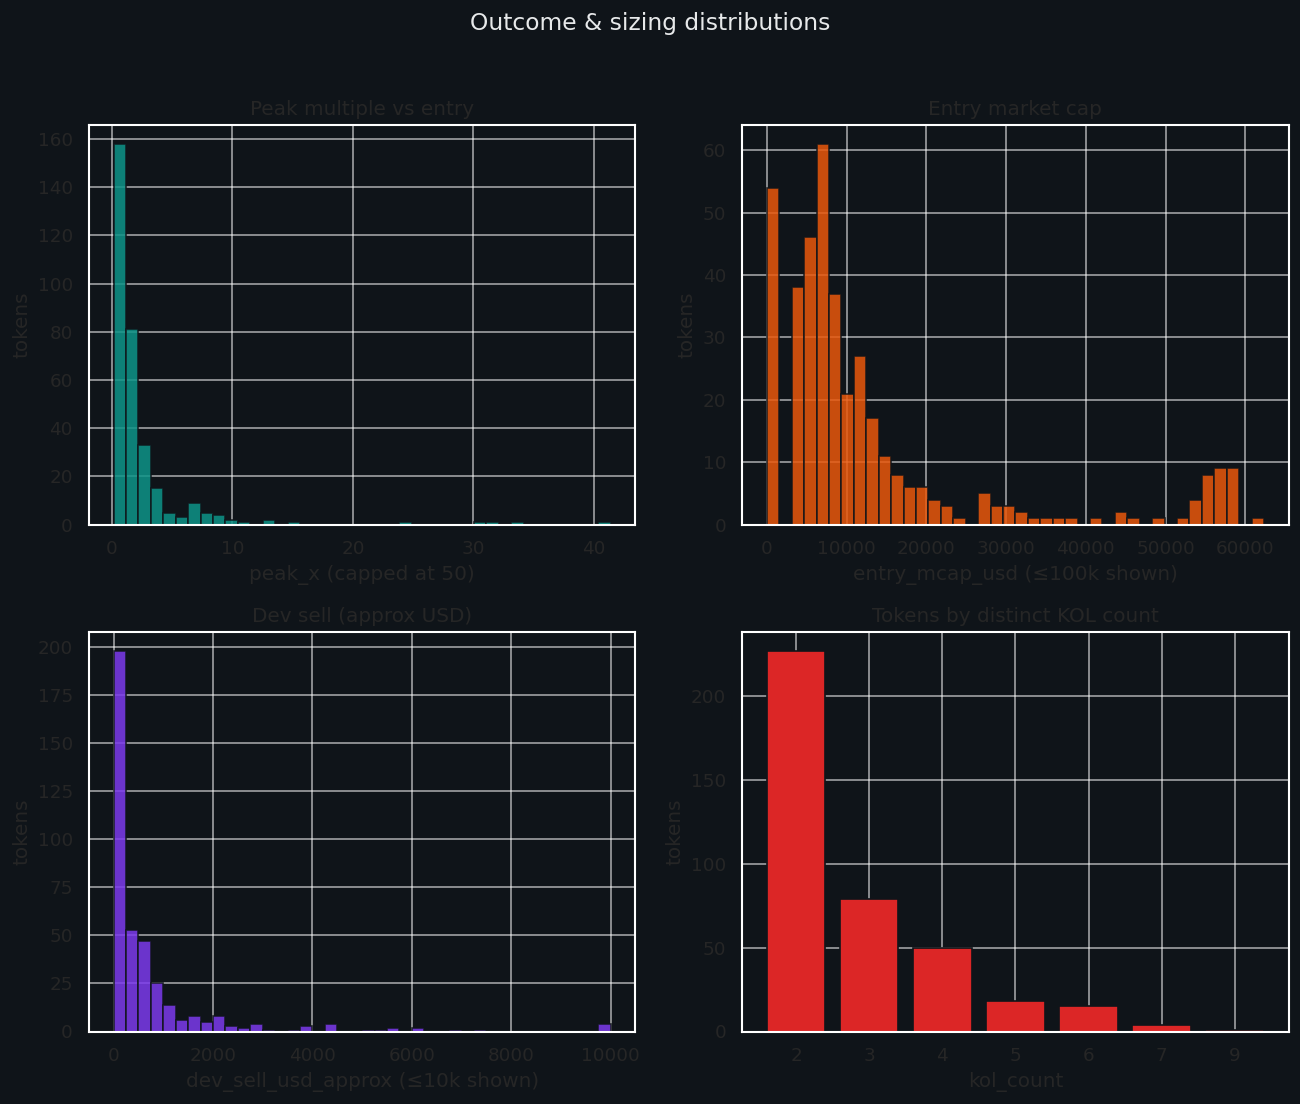

In [5]:
fig, axes = plt.subplots(2, 2, figsize=(11, 9))
fig.suptitle("Outcome & sizing distributions", fontsize=14, color=FG, y=1.02)

ax = axes[0, 0]
x = df.loc[df["peak_x"] > 0, "peak_x_capped"]
ax.hist(x, bins=40, color=PALETTE[0], edgecolor=BG, alpha=0.85)
ax.set_xlabel("peak_x (capped at 50)")
ax.set_ylabel("tokens")
ax.set_title("Peak multiple vs entry")

ax = axes[0, 1]
ax.hist(df["entry_mcap_usd"].clip(upper=100_000), bins=40, color=PALETTE[1], edgecolor=BG, alpha=0.85)
ax.set_xlabel("entry_mcap_usd (≤100k shown)")
ax.set_ylabel("tokens")
ax.set_title("Entry market cap")

ax = axes[1, 0]
ax.hist(df["dev_sell_usd_approx"].clip(upper=10_000), bins=40, color=PALETTE[2], edgecolor=BG, alpha=0.85)
ax.set_xlabel("dev_sell_usd_approx (≤10k shown)")
ax.set_ylabel("tokens")
ax.set_title("Dev sell (approx USD)")

ax = axes[1, 1]
kc = df["kol_count"].value_counts().sort_index()
bars = ax.bar(kc.index.astype(str), kc.values, color=PALETTE[3], edgecolor=BG)
ax.set_xlabel("kol_count")
ax.set_ylabel("tokens")
ax.set_title("Tokens by distinct KOL count")

plt.tight_layout()
plt.show()

## 3. Peak performance by `kol_count`

,kol_count,n,peak_x_mean,peak_x_median,pct_ge_2x,pct_ge_5x
0,2,227,1.21,1.04,11.89,1.76
1,3,79,1.67,1.12,26.58,6.33
2,4,50,2.89,1.56,46.00,26.00
3,5,18,7.73,3.02,61.11,38.89
4,6,15,5.72,1.51,40.00,26.67
5,7,4,11.87,2.54,75.00,25.00
6,9,1,1.83,1.83,0.00,0.00


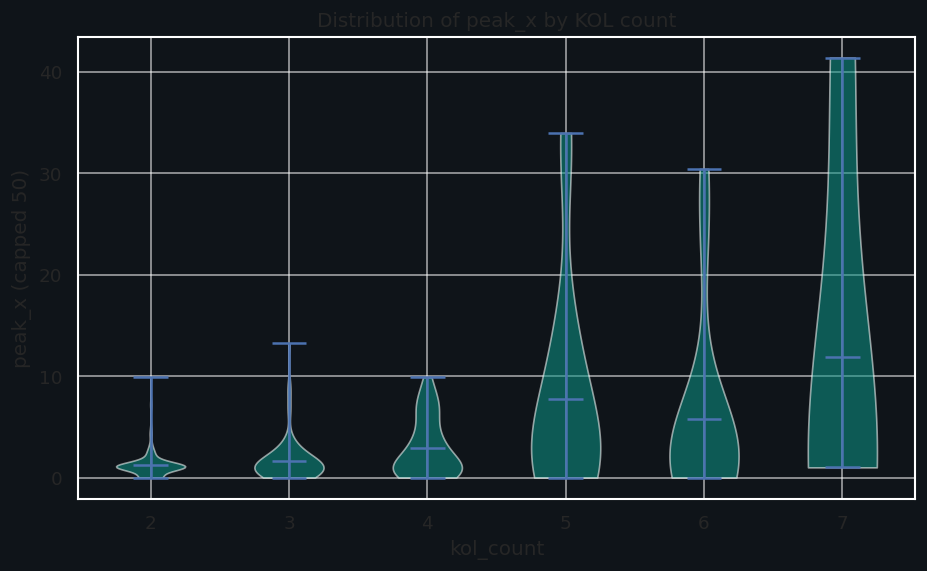

In [6]:
by_k = (
    df.groupby("kol_count")
    .agg(
        n=("token", "count"),
        peak_x_mean=("peak_x", "mean"),
        peak_x_median=("peak_x", "median"),
        pct_ge_2x=("peak_x", lambda s: (s >= 2).mean() * 100),
        pct_ge_5x=("peak_x", lambda s: (s >= 5).mean() * 100),
    )
    .reset_index()
)
display(by_k.round(2))

fig, ax = plt.subplots(figsize=(9, 5))
sub = df[df["kol_count"] <= 8]
parts = ax.violinplot(
    [sub.loc[sub["kol_count"] == k, "peak_x_capped"].values for k in sorted(sub["kol_count"].unique())],
    positions=sorted(sub["kol_count"].unique()),
    showmeans=True,
    showmedians=False,
)
for b in parts["bodies"]:
    b.set_facecolor(PALETTE[0])
    b.set_alpha(0.55)
ax.set_xticks(sorted(sub["kol_count"].unique()))
ax.set_xlabel("kol_count")
ax.set_ylabel("peak_x (capped 50)")
ax.set_title("Distribution of peak_x by KOL count")
plt.show()

## 4. Scatter: entry mcap vs peak (colored by dev sell)

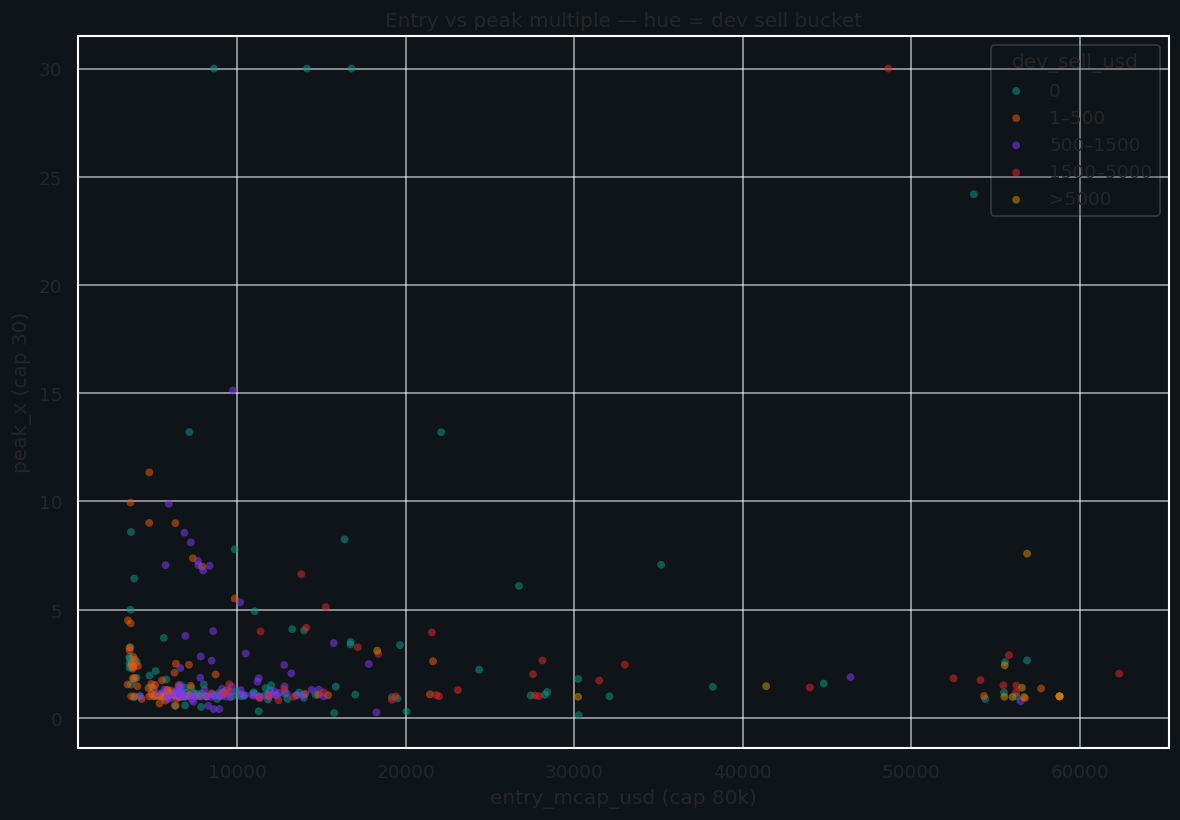

In [7]:
sub = df[(df["entry_mcap_usd"] > 100) & (df["peak_x"] > 0)].copy()
sub["dev_bucket"] = pd.cut(
    sub["dev_sell_usd_approx"],
    bins=[-1, 0, 500, 1500, 5000, sub["dev_sell_usd_approx"].max() + 1],
    labels=["0", "1–500", "500–1500", "1500–5000", ">5000"],
)

fig, ax = plt.subplots(figsize=(10, 7))
for i, cat in enumerate(sub["dev_bucket"].cat.categories):
    m = sub["dev_bucket"] == cat
    ax.scatter(
        sub.loc[m, "entry_mcap_usd"].clip(upper=80_000),
        sub.loc[m, "peak_x"].clip(upper=30),
        s=22,
        alpha=0.55,
        c=PALETTE[i % len(PALETTE)],
        label=str(cat),
        edgecolors="none",
    )
ax.set_xlabel("entry_mcap_usd (cap 80k)")
ax.set_ylabel("peak_x (cap 30)")
ax.set_title("Entry vs peak multiple — hue = dev sell bucket")
ax.legend(title="dev_sell_usd", framealpha=0.2)
plt.tight_layout()
plt.show()

## 5. Correlation heatmap (numeric features)

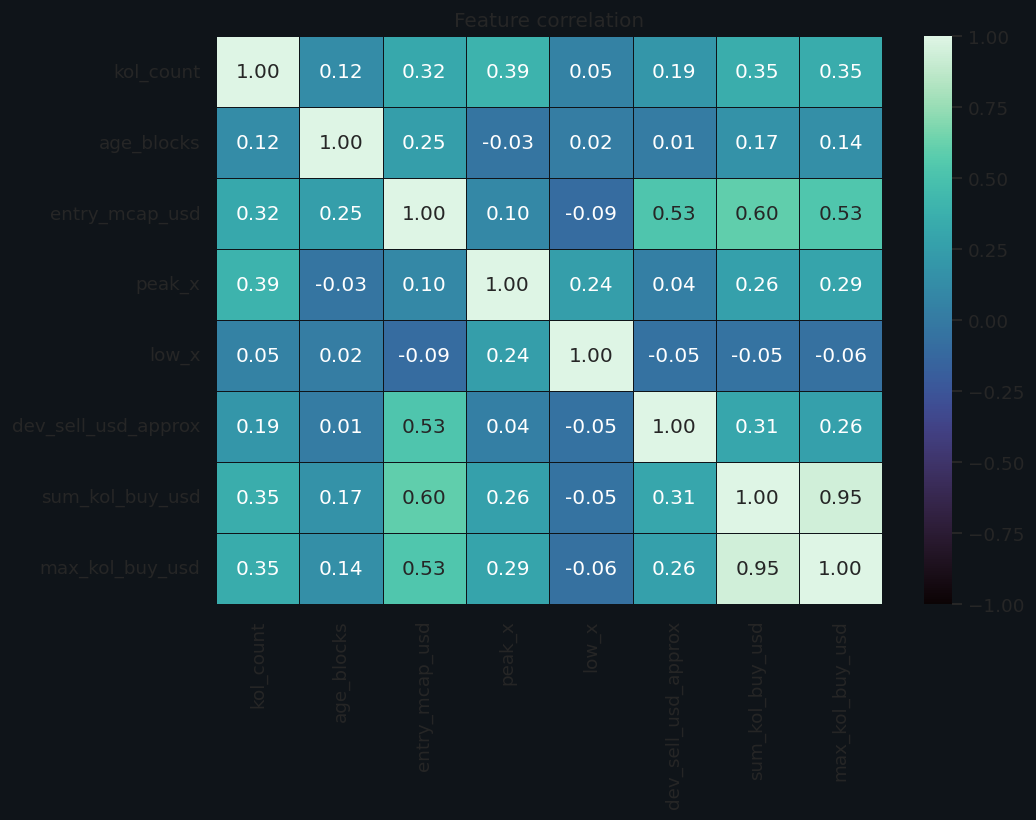

In [8]:
num_cols = [
    "kol_count", "age_blocks", "entry_mcap_usd", "peak_x", "low_x",
    "dev_sell_usd_approx", "sum_kol_buy_usd", "max_kol_buy_usd",
]
cm = df[num_cols].corr()
fig, ax = plt.subplots(figsize=(9, 7))
sns.heatmap(
    cm,
    annot=True,
    fmt=".2f",
    cmap="mako",
    vmin=-1,
    vmax=1,
    ax=ax,
    linewidths=0.5,
    linecolor=BG,
)
ax.set_title("Feature correlation")
plt.tight_layout()
plt.show()

## 6. Per-KOL buy notionals (1st vs 2nd KOL)

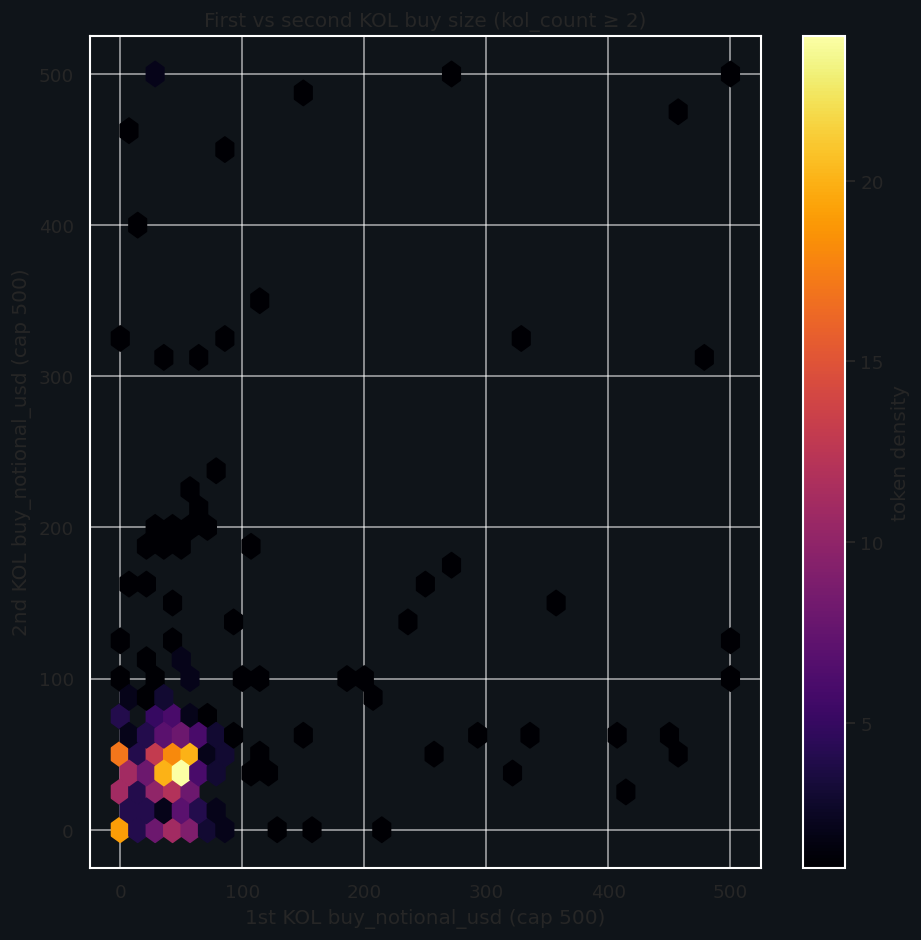

In [9]:
two_plus = df[df["kol_count"] >= 2]
fig, ax = plt.subplots(figsize=(8, 8))
ax.hexbin(
    two_plus["first_kol_buy_usd"].clip(upper=500),
    two_plus["second_kol_buy_usd"].clip(upper=500),
    gridsize=35,
    cmap="inferno",
    mincnt=1,
)
cb = plt.colorbar(ax.collections[0], ax=ax)
cb.set_label("token density")
ax.set_xlabel("1st KOL buy_notional_usd (cap 500)")
ax.set_ylabel("2nd KOL buy_notional_usd (cap 500)")
ax.set_title("First vs second KOL buy size (kol_count ≥ 2)")
plt.tight_layout()
plt.show()

## 7. Interactive Plotly explorer

Pan/zoom/hover — useful for spotting outliers.

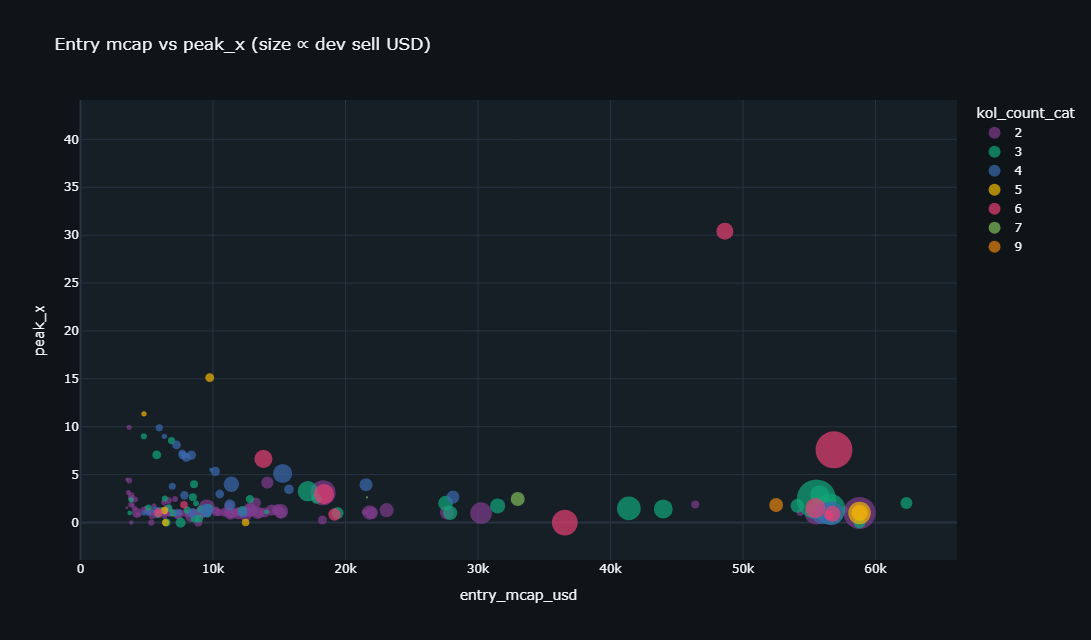

In [10]:
plot_df = df[(df["entry_mcap_usd"] > 0) | (df["peak_x"] > 0)].copy()
plot_df["label"] = plot_df["name"].str.slice(0, 40) + " | " + plot_df["token"].str.slice(0, 10) + "…"
plot_df["kol_count_cat"] = plot_df["kol_count"].astype(str)

fig = px.scatter(
    plot_df,
    x="entry_mcap_usd",
    y="peak_x",
    color="kol_count_cat",
    size="dev_sell_usd_approx",
    size_max=28,
    hover_name="label",
    hover_data={
        "graduated": True,
        "dev_sell_usd_approx": ":,.0f",
        "sum_kol_buy_usd": ":,.0f",
        "age_blocks": True,
    },
    color_discrete_sequence=px.colors.qualitative.Bold,
    title="Entry mcap vs peak_x (size ∝ dev sell USD)",
)
fig.update_layout(
    template="plotly_dark",
    paper_bgcolor="#0f1419",
    plot_bgcolor="#161e26",
    height=640,
)
fig.update_traces(marker=dict(line=dict(width=0)))
fig.show()

## 8. KOL sequence: average notional by buy index

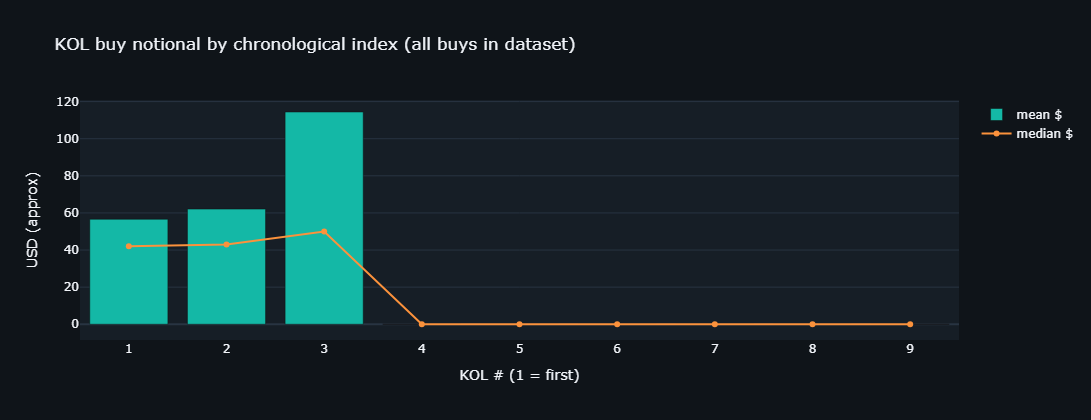

,kol_index,mean,median,count
0,1,56.6,42.0,394
1,2,62.1,43.0,394
2,3,114.4,50.0,167
3,4,0.0,0.0,88
4,5,0.0,0.0,38
5,6,0.0,0.0,20
6,7,0.0,0.0,5
7,8,0.0,0.0,1
8,9,0.0,0.0,1


In [11]:
seq = (
    df_long.groupby("kol_index")["buy_notional_usd_approx"]
    .agg(mean="mean", median="median", count="count")
    .reset_index()
)
fig = go.Figure()
fig.add_trace(go.Bar(x=seq["kol_index"], y=seq["mean"], name="mean $", marker_color="#14b8a6"))
fig.add_trace(go.Scatter(x=seq["kol_index"], y=seq["median"], name="median $", mode="lines+markers", line=dict(color="#fb923c")))
fig.update_layout(
    template="plotly_dark",
    title="KOL buy notional by chronological index (all buys in dataset)",
    xaxis_title="KOL # (1 = first)",
    yaxis_title="USD (approx)",
    paper_bgcolor="#0f1419",
    plot_bgcolor="#161e26",
    height=420,
)
fig.show()
display(seq.round(1))

---

### Tips

- Point `JSONL_PATH` at full or filtered files (`filter_kol_jsonl.py` output).
- For huge files, add `df = df.sample(2000, random_state=42)` after load.
- Export Plotly: `fig.write_html(REPO / "backtest_results" / "scatter.html")`.